In [45]:
from pathlib import Path

import fiona
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

BASE_DIR = Path(r"C:\Soilgrids")
DATA_DIR = BASE_DIR / 'data'
TDR_DIR = BASE_DIR / 'TDR_data'
RESULTS_DIR = BASE_DIR / 'resultados'
FIGURES_DIR = BASE_DIR / 'analysis' / 'results_figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

GPKG_PATH = DATA_DIR / 'Ubicacion_Estacion Principal.gpkg'
TDR_RAW_PATH = TDR_DIR / 'TDR_ladera_zhurucay_2021_09_2026_03.csv'
TDR_DAILY_PATH = TDR_DIR / 'TDR_ladera_zhurucay_daily_avg.csv'
TDR_DAILY_MEAN_PATH = TDR_DIR / 'TDR_ladera_zhurucay_daily_mean_all_sensors.csv'
TDR_CLEAN_PATH = RESULTS_DIR / 'TDR_ladera_zhurucay_daily_mean_all_sensors_clean.csv'
SMAP_PATH = TDR_DIR / 'SMAP_RZ_clean.csv'
MISSING_DATES_PATH = RESULTS_DIR / 'missing_dates_daily_mean_all_sensors.csv'
MISSING_GAPS_PATH = RESULTS_DIR / 'missing_gaps_summary_daily_mean_all_sensors.csv'
COMPARISON_DAILY_PATH = RESULTS_DIR / 'comparison_smap_vs_tdr_daily.csv'
COMPARISON_OVERLAP_PATH = RESULTS_DIR / 'comparison_smap_vs_tdr_overlap_only.csv'


def normalize_dates(dataframe, column_name):
    dataframe = dataframe.copy()
    dataframe[column_name] = pd.to_datetime(dataframe[column_name]).dt.normalize()
    return dataframe


def save_figure(fig, filename, dpi=150):
    output_path = FIGURES_DIR / filename
    fig.savefig(output_path, dpi=dpi, bbox_inches='tight')
    print(f"Visualization saved to: {output_path}")
    return output_path


def load_smap_daily():
    smap = pd.read_csv(SMAP_PATH, parse_dates=['datetime'])
    smap = normalize_dates(smap, 'datetime')
    smap = smap.rename(columns={'datetime': 'Date'})
    return (
        smap.groupby('Date', as_index=False)['soil_moisture']
        .mean()
        .sort_values('Date')
    )


def load_tdr_clean():
    tdr = pd.read_csv(TDR_CLEAN_PATH, parse_dates=['Date'])
    tdr = normalize_dates(tdr, 'Date')
    return tdr[['Date', 'VW_mean_all_sensors']].dropna().sort_values('Date')


if GPKG_PATH.exists():
    layers = fiona.listlayers(GPKG_PATH)
    records = []
    source_crs = None

    for layer_name in layers:
        gdf = gpd.read_file(GPKG_PATH, layer=layer_name)
        if gdf.empty:
            continue

        point_rows = gdf[gdf.geometry.geom_type.isin(['Point', 'MultiPoint'])].copy()
        if point_rows.empty:
            continue

        source_crs = gdf.crs
        point_rows['x'] = point_rows.geometry.x
        point_rows['y'] = point_rows.geometry.y
        point_rows['layer'] = layer_name

        if source_crs is not None:
            point_rows_wgs84 = point_rows.to_crs(4326)
            point_rows['longitude'] = point_rows_wgs84.geometry.x
            point_rows['latitude'] = point_rows_wgs84.geometry.y
        else:
            point_rows['longitude'] = pd.NA
            point_rows['latitude'] = pd.NA

        records.append(point_rows[['layer', 'x', 'y', 'longitude', 'latitude', 'geometry']])

    if not records:
        raise ValueError('No point geometries were found in the geopackage.')

    coords_df = pd.concat(records, ignore_index=True)
    print(f'Layers: {list(layers)}')
    print(f'Source CRS: {source_crs}')
else:
    coords_df = pd.DataFrame(columns=['layer', 'x', 'y', 'longitude', 'latitude', 'geometry'])
    print(f'Geopackage not found, skipping coordinate extraction: {GPKG_PATH}')

coords_df

Layers: ['Ubicacion_Estacion Principal']
Source CRS: EPSG:24877


,layer,x,y,longitude,latitude,geometry
0,Ubicacion_Estacion Principal,696444.80038,9.661710e+06,-79.234636,-3.062424,POINT (696444.8 9661710.265)


Raw rows: 894,251
Sensors available: 12
Sensors used in boxplots: 12 (includes VW_Avg(21))
Sensors used for downstream SMAP analysis: 11
Excluded from downstream SMAP analysis: ['VW_Avg(21)']
['VW_Avg(14)', 'VW_Avg(15)', 'VW_Avg(16)', 'VW_Avg(17)', 'VW_Avg(18)', 'VW_Avg(19)', 'VW_Avg(20)', 'VW_Avg(21)', 'VW_Avg(22)', 'VW_Avg(23)', 'VW_Avg(24)', 'VW_Avg(25)']

Invalid-value summary (outside [0, 1]):
    sensor  total_obs  invalid_obs  min_value  max_value  invalid_pct
VW_Avg(21)     402679            9     -0.004      0.765     0.002235
VW_Avg(19)     402681            3     -0.006      0.810     0.000745
VW_Avg(17)     138058            1  -8126.000      0.880     0.000724
VW_Avg(14)     402683            0      0.013      0.781     0.000000
VW_Avg(16)     402683            0      0.012      0.784     0.000000
VW_Avg(15)     402683            0      0.012      0.775     0.000000
VW_Avg(18)     256733            0      0.013      0.789     0.000000
VW_Avg(20)     402681            0    

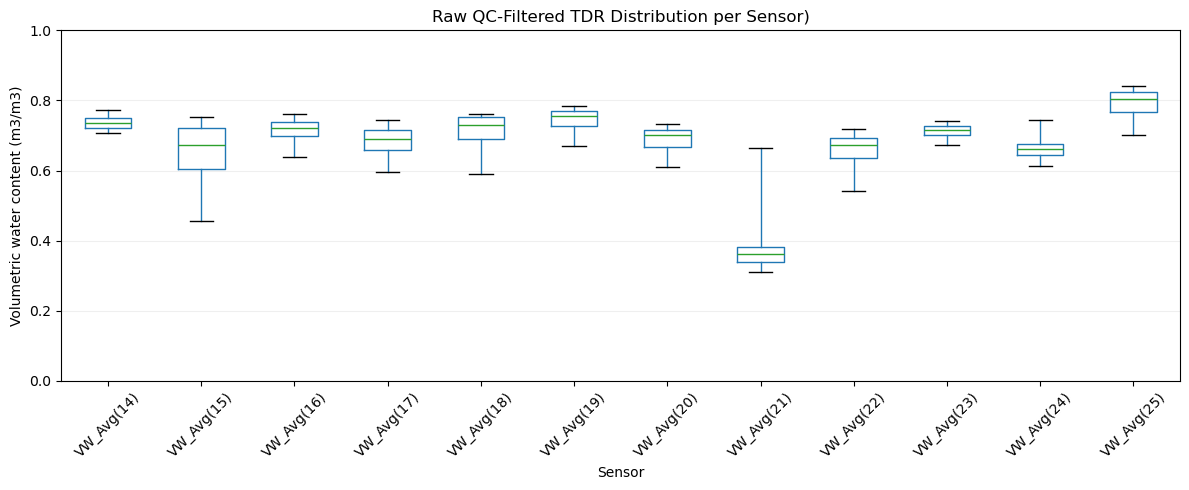

Visualization saved to: C:\Soilgrids\analysis\results_figures\results_sm_sensor_boxplot_daily_weekly_monthly_with21.png


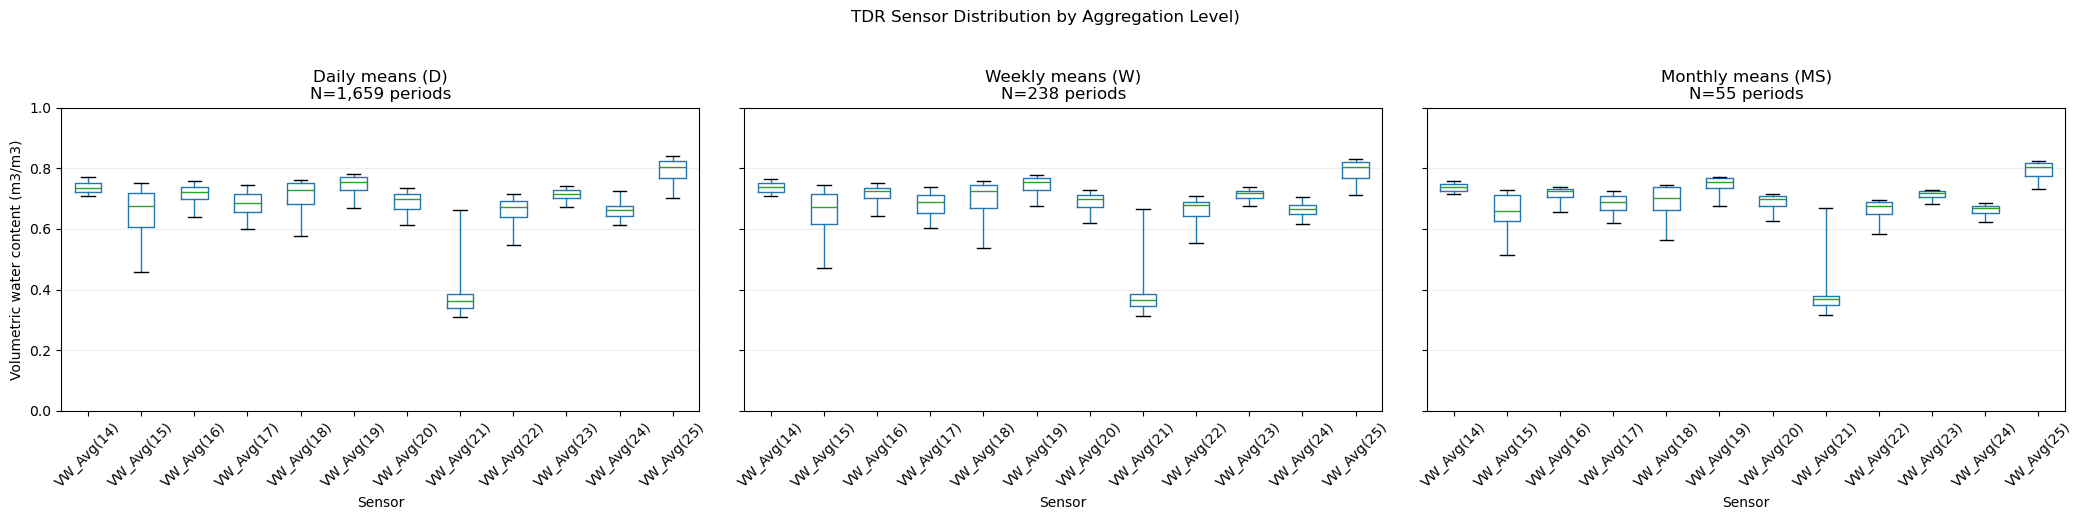

In [46]:
# Inspect and smooth TDR sensor distributions before daily aggregation
df_tdr_raw = pd.read_csv(TDR_RAW_PATH, parse_dates=['TIMESTAMP'])

# Prefer volumetric water-content columns if available; otherwise use numeric sensor-like columns
vw_columns = [column for column in df_tdr_raw.columns if column.lower().startswith('vw')]
if vw_columns:
    sensor_columns = vw_columns
else:
    sensor_columns = [
        column
        for column in df_tdr_raw.select_dtypes(include=[np.number]).columns
        if column.lower() not in {'record'}
    ]

if not sensor_columns:
    raise ValueError('No numeric sensor columns were found in the raw TDR file.')

# Keep all sensors for boxplots, but exclude VW_Avg(21) for downstream SMAP analysis
excluded_sensors = {'VW_Avg(21)'}
analysis_sensor_columns = [column for column in sensor_columns if column not in excluded_sensors]
if not analysis_sensor_columns:
    raise ValueError('No sensors left after applying exclusion list.')

qc_min, qc_max = 0.0, 1.0
sensor_wide_all = (
    df_tdr_raw[['TIMESTAMP'] + sensor_columns]
    .drop_duplicates(subset='TIMESTAMP')
    .sort_values('TIMESTAMP')
    .set_index('TIMESTAMP')
)
sensor_wide_analysis = sensor_wide_all[analysis_sensor_columns]

# Keep only physically plausible volumetric water content values
qc_mask_all = (sensor_wide_all >= qc_min) & (sensor_wide_all <= qc_max)
sensor_wide_qc_all = sensor_wide_all.where(qc_mask_all)

qc_mask_analysis = (sensor_wide_analysis >= qc_min) & (sensor_wide_analysis <= qc_max)
sensor_wide_qc = sensor_wide_analysis.where(qc_mask_analysis)

long_all = sensor_wide_all.reset_index().melt(
    id_vars='TIMESTAMP',
    value_vars=sensor_columns,
    var_name='sensor',
    value_name='value'
).dropna(subset=['value'])

invalid_summary = (
    long_all.assign(is_invalid=~long_all['value'].between(qc_min, qc_max))
    .groupby('sensor', as_index=False)
    .agg(
        total_obs=('value', 'size'),
        invalid_obs=('is_invalid', 'sum'),
        min_value=('value', 'min'),
        max_value=('value', 'max')
    )
 )
invalid_summary['invalid_pct'] = 100 * invalid_summary['invalid_obs'] / invalid_summary['total_obs']

print(f'Raw rows: {len(df_tdr_raw):,}')
print(f'Sensors available: {len(sensor_columns)}')
print(f'Sensors used in boxplots: {len(sensor_columns)} (includes VW_Avg(21))')
print(f'Sensors used for downstream SMAP analysis: {len(analysis_sensor_columns)}')
print(f'Excluded from downstream SMAP analysis: {sorted(excluded_sensors)}')
print(sensor_columns)
print('\nInvalid-value summary (outside [0, 1]):')
print(invalid_summary.sort_values('invalid_pct', ascending=False).to_string(index=False))

# Smoothed raw boxplot: hide fliers and use percentile whiskers
fig_raw, ax_raw = plt.subplots(figsize=(12, 5))
sensor_wide_qc_all.boxplot(
    ax=ax_raw,
    rot=45,
    showfliers=False,
    whis=[5, 95],
    grid=False
 )
ax_raw.set_title('Raw QC-Filtered TDR Distribution per Sensor)')
ax_raw.set_xlabel('Sensor')
ax_raw.set_ylabel('Volumetric water content (m3/m3)')
ax_raw.set_ylim(qc_min, qc_max)
ax_raw.grid(alpha=0.2, axis='y')
fig_raw.tight_layout()
save_figure(fig_raw, 'results_sm_raw_tdr_sensor_boxplot_smoothed_with21.png')
plt.show()

# Compare aggregation scales to choose smoothing level
aggregation_map = {
    'Daily means (D)': 'D',
    'Weekly means (W)': 'W',
    'Monthly means (MS)': 'MS',
}

fig_cmp, axes_cmp = plt.subplots(1, 3, figsize=(21, 5), sharey=True)

for axis, (label, freq) in zip(axes_cmp, aggregation_map.items()):
    aggregated = sensor_wide_qc_all.resample(freq).mean()
    aggregated.boxplot(
        ax=axis,
        rot=45,
        showfliers=False,
        whis=[5, 95],
        grid=False
    )
    axis.set_title(f'{label}\nN={len(aggregated):,} periods')
    axis.set_xlabel('Sensor')
    axis.set_ylim(qc_min, qc_max)
    axis.grid(alpha=0.2, axis='y')

axes_cmp[0].set_ylabel('Volumetric water content (m3/m3)')
fig_cmp.suptitle('TDR Sensor Distribution by Aggregation Level)', y=1.03)
fig_cmp.tight_layout()
save_figure(fig_cmp, 'results_sm_sensor_boxplot_daily_weekly_monthly_with21.png')
plt.show()

Visualization saved to: C:\Soilgrids\analysis\results_figures\results_sm_sensor_boxplot_with_stats_with21.png


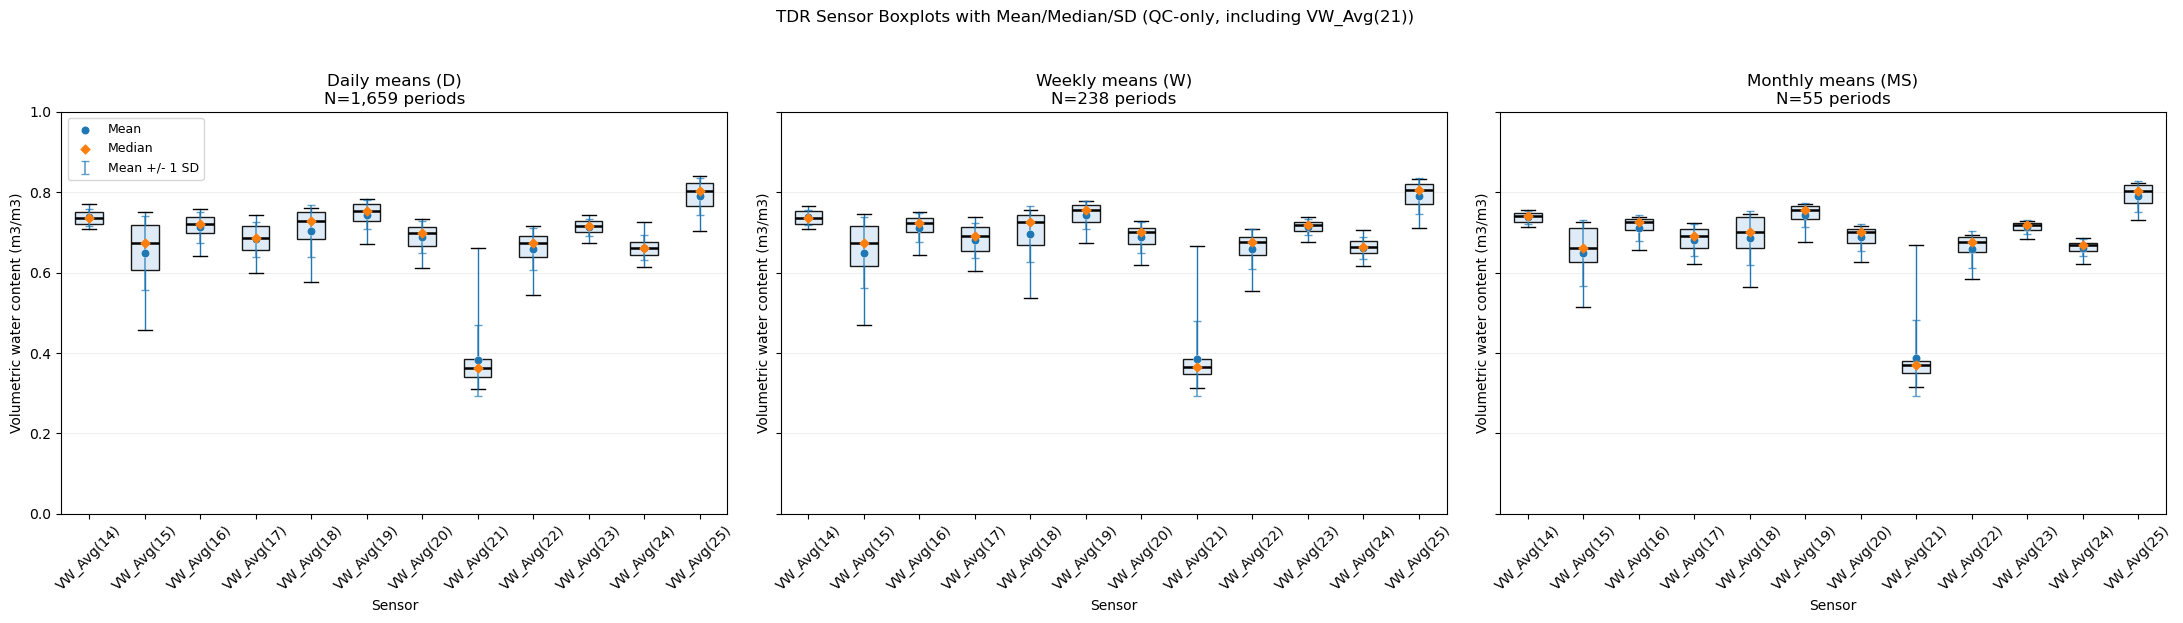

Stats table saved to: C:\Soilgrids\resultados\tdr_sensor_stats_daily_weekly_monthly_with21.csv


,aggregation,sensor,mean,median,std
0,Daily means (D),VW_Avg(14),0.737442,0.736219,0.020365
1,Daily means (D),VW_Avg(15),0.649374,0.674726,0.092341
2,Daily means (D),VW_Avg(16),0.712782,0.721125,0.038756
3,Daily means (D),VW_Avg(17),0.683312,0.687000,0.043839
4,Daily means (D),VW_Avg(18),0.704474,0.727868,0.064979
5,Daily means (D),VW_Avg(19),0.744475,0.754580,0.035677
6,Daily means (D),VW_Avg(20),0.687752,0.699854,0.039852
7,Daily means (D),VW_Avg(21),0.382181,0.363365,0.088658
8,Daily means (D),VW_Avg(22),0.658305,0.672861,0.052564
9,Daily means (D),VW_Avg(23),0.713190,0.716747,0.021479


In [47]:
# Boxplots with mean, median, and standard deviation annotations for each TDR sensor
if 'sensor_wide_qc_all' not in globals() or sensor_wide_qc_all.empty:
    raise ValueError("Run Cell 2 first so 'sensor_wide_qc_all' is available.")

def plot_box_with_stats(ax, data, title, y_min=0.0, y_max=1.0):
    if data.empty:
        ax.set_title(f"{title}\n(no data)")
        ax.axis('off')
        return None

    # Boxplot keeps the median line; mean marker is enabled and outliers are hidden.
    data.boxplot(
        ax=ax,
        rot=45,
        showfliers=False,
        whis=[5, 95],
        showmeans=True,
        meanline=False,
        patch_artist=True,
        boxprops=dict(facecolor='#dceaf7', alpha=0.9),
        medianprops=dict(color='black', linewidth=1.8),
        meanprops=dict(marker='o', markerfacecolor='tab:blue', markeredgecolor='white', markersize=5),
        grid=False
    )

    means = data.mean()
    medians = data.median()
    stds = data.std()
    positions = np.arange(1, len(data.columns) + 1)

    # Overlay explicit symbols and SD bars so statistics are visible in one figure.
    ax.errorbar(
        positions,
        means.values,
        yerr=stds.values,
        fmt='none',
        ecolor='tab:blue',
        elinewidth=1.2,
        capsize=3,
        alpha=0.7,
        label='Mean +/- 1 SD'
    )
    ax.scatter(positions, means.values, color='tab:blue', s=22, zorder=3, label='Mean')
    ax.scatter(positions, medians.values, color='tab:orange', marker='D', s=20, zorder=3, label='Median')

    ax.set_title(f"{title}\nN={len(data):,} periods")
    ax.set_xlabel('Sensor')
    ax.set_ylabel('Volumetric water content (m3/m3)')
    ax.set_ylim(y_min, y_max)
    ax.grid(alpha=0.2, axis='y')

    stats_table = pd.DataFrame({
        'sensor': data.columns,
        'mean': means.values,
        'median': medians.values,
        'std': stds.values
    })

    return stats_table

agg_map = {
    'Daily means (D)': 'D',
    'Weekly means (W)': 'W',
    'Monthly means (MS)': 'MS',
}

fig_stats, axes_stats = plt.subplots(1, 3, figsize=(22, 6), sharey=True)
stats_outputs = []

for idx, (label, freq) in enumerate(agg_map.items()):
    aggregated = sensor_wide_qc_all.resample(freq).mean()
    stats_df = plot_box_with_stats(axes_stats[idx], aggregated, label, y_min=qc_min, y_max=qc_max)
    if stats_df is not None:
        stats_df.insert(0, 'aggregation', label)
        stats_outputs.append(stats_df)

# Show a single clean legend
handles, labels = axes_stats[0].get_legend_handles_labels()
if handles:
    axes_stats[0].legend(handles[:3], labels[:3], loc='upper left', fontsize=9)

fig_stats.suptitle('TDR Sensor Boxplots with Mean/Median/SD (QC-only, including VW_Avg(21))', y=1.03)
fig_stats.tight_layout()
save_figure(fig_stats, 'results_sm_sensor_boxplot_with_stats_with21.png')
plt.show()

if stats_outputs:
    stats_summary = pd.concat(stats_outputs, ignore_index=True)
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)
    stats_summary_path = RESULTS_DIR / 'tdr_sensor_stats_daily_weekly_monthly_with21.csv'
    stats_summary.to_csv(stats_summary_path, index=False)
    print(f'Stats table saved to: {stats_summary_path}')
    display(stats_summary.head(12))

In [48]:
# Compare overall mean including all sensors vs excluding VW_Avg(21) across time scales
if 'df_tdr_raw' not in globals() or df_tdr_raw.empty:
    raise ValueError("Run Cell 2 first so raw TDR data is loaded.")

vw_all = [column for column in df_tdr_raw.columns if column.lower().startswith('vw')]
if 'VW_Avg(21)' not in vw_all:
    raise ValueError('VW_Avg(21) not found in raw VW columns.')

full_sensor_wide = (
    df_tdr_raw[['TIMESTAMP'] + vw_all]
    .drop_duplicates(subset='TIMESTAMP')
    .sort_values('TIMESTAMP')
    .set_index('TIMESTAMP')
)
full_sensor_wide_qc = full_sensor_wide.where((full_sensor_wide >= 0.0) & (full_sensor_wide <= 1.0))

comparisons = []
scale_map = {
    'Raw (all timestamps)': full_sensor_wide_qc,
    'Daily means': full_sensor_wide_qc.resample('D').mean(),
    'Weekly means': full_sensor_wide_qc.resample('W').mean(),
    'Monthly means': full_sensor_wide_qc.resample('MS').mean(),
}

for scale_name, frame in scale_map.items():
    frame = frame.dropna(how='all')
    all_mean = frame.mean(axis=1).mean()
    without_21_mean = frame.drop(columns=['VW_Avg(21)']).mean(axis=1).mean()
    abs_diff = without_21_mean - all_mean
    pct_diff = (abs_diff / all_mean) * 100 if pd.notna(all_mean) and all_mean != 0 else np.nan

    comparisons.append({
        'scale': scale_name,
        'mean_all_sensors': all_mean,
        'mean_without_vw_avg_21': without_21_mean,
        'absolute_difference': abs_diff,
        'percent_difference': pct_diff,
    })

comparison_df = pd.DataFrame(comparisons)
print(comparison_df.to_string(index=False, float_format=lambda value: f'{value:.6f}'))

               scale  mean_all_sensors  mean_without_vw_avg_21  absolute_difference  percent_difference
Raw (all timestamps)          0.675905                0.705330             0.029425            4.353441
         Daily means          0.676134                0.705017             0.028883            4.271778
        Weekly means          0.676438                0.704116             0.027678            4.091705
       Monthly means          0.675939                0.702546             0.026606            3.936220


In [49]:
# Build QC-only TDR daily means (sensor VW_Avg(21) already removed in Cell 2)
if 'sensor_wide_qc' not in globals() or sensor_wide_qc.empty:
    raise ValueError("Run Cell 2 first so 'sensor_wide_qc' is available.")

df_day = sensor_wide_qc.resample('D').mean()
df_day.index.name = 'Date'

df_day.to_csv(TDR_DAILY_PATH)

print(f'Daily QC-only sensor averages saved to: {TDR_DAILY_PATH}')
print(f'Shape: {df_day.shape}')
df_day.head()

Daily QC-only sensor averages saved to: C:\Soilgrids\TDR_data\TDR_ladera_zhurucay_daily_avg.csv
Shape: (1659, 11)


,VW_Avg(14),VW_Avg(15),VW_Avg(16),VW_Avg(17),VW_Avg(18),VW_Avg(19),VW_Avg(20),VW_Avg(22),VW_Avg(23),VW_Avg(24),VW_Avg(25)
Date,,,,,,,,,,,
2021-09-10,0.732906,0.702226,0.726562,0.692944,0.734441,0.762181,0.705681,0.678861,0.722021,0.661292,0.819569
2021-09-11,0.733330,0.715705,0.727122,0.691111,0.739132,0.762163,0.706198,0.681104,0.722816,0.661615,0.824972
2021-09-12,0.740552,0.736747,0.740740,0.713205,0.751632,0.772743,0.720292,0.700215,0.733312,0.696274,0.837531
2021-09-13,0.768399,0.747740,0.757146,0.743052,0.759663,0.778705,0.721969,0.707507,0.733139,0.687767,0.836868
2021-09-14,0.759649,0.722806,0.740396,0.729174,0.748774,0.770851,0.712701,0.686802,0.728819,0.672569,0.826424


In [50]:
# Compute daily mean across QC-filtered sensors (VW_Avg(21) excluded)
df_day_mean = df_day.mean(axis=1).rename('VW_mean_all_sensors').to_frame()
df_day_mean.index.name = 'Date'

df_day_mean.to_csv(TDR_DAILY_MEAN_PATH)

print(f'Saved to: {TDR_DAILY_MEAN_PATH}')
print(f'Shape: {df_day_mean.shape}')
df_day_mean.head()

Saved to: C:\Soilgrids\TDR_data\TDR_ladera_zhurucay_daily_mean_all_sensors.csv
Shape: (1659, 1)


,VW_mean_all_sensors
Date,
2021-09-10,0.721699
2021-09-11,0.724115
2021-09-12,0.740295
2021-09-13,0.749269
2021-09-14,0.736270


In [51]:
# Find missing dates in the daily mean soil moisture series
df_daily = pd.read_csv(TDR_DAILY_MEAN_PATH, parse_dates=['Date'])
df_daily = normalize_dates(df_daily, 'Date')
df_daily = df_daily.drop_duplicates(subset='Date').sort_values('Date').set_index('Date')

full_days = pd.date_range(df_daily.index.min(), df_daily.index.max(), freq='D')
missing_from_index = full_days.difference(df_daily.index)
nan_days = df_daily.index[df_daily['VW_mean_all_sensors'].isna()]
all_missing_days = pd.DatetimeIndex(sorted(set(missing_from_index).union(set(nan_days))))

missing_dates_df = pd.DataFrame({'date': all_missing_days.date})
missing_dates_df.to_csv(MISSING_DATES_PATH, index=False)

gap_rows = []
if len(all_missing_days) > 0:
    missing_series = pd.Series(all_missing_days)
    group_id = missing_series.diff().dt.days.ne(1).cumsum()

    for _, group in missing_series.groupby(group_id):
        gap_rows.append({
            'start_date': group.iloc[0].date(),
            'end_date': group.iloc[-1].date(),
            'length_days': int(len(group))
        })

gaps_df = (
    pd.DataFrame(gap_rows).sort_values('length_days', ascending=False)
    if gap_rows
    else pd.DataFrame(columns=['start_date', 'end_date', 'length_days'])
)
gaps_df.to_csv(MISSING_GAPS_PATH, index=False)

print('Missing-date audit complete for daily mean CSV')
print(f'Date range checked: {full_days.min().date()} to {full_days.max().date()}')
print(f'Missing from index: {len(missing_from_index)}')
print(f'NaN days in VW_mean_all_sensors: {len(nan_days)}')
print(f'Total unique missing dates: {len(all_missing_days)}')
print(f'Saved missing dates to: {MISSING_DATES_PATH}')
print(f'Saved gap summary to: {MISSING_GAPS_PATH}')

if len(all_missing_days) > 0:
    print('\nFirst 30 missing dates:')
    print(pd.Series(all_missing_days.date).head(30).to_string(index=False))

if len(gaps_df) > 0:
    print('\nTop 10 largest consecutive missing-date gaps:')
    print(gaps_df.head(10).to_string(index=False))

gaps_df.head(10)

Missing-date audit complete for daily mean CSV
Date range checked: 2021-09-10 to 2026-03-26
Missing from index: 0
NaN days in VW_mean_all_sensors: 246
Total unique missing dates: 246
Saved missing dates to: C:\Soilgrids\resultados\missing_dates_daily_mean_all_sensors.csv
Saved gap summary to: C:\Soilgrids\resultados\missing_gaps_summary_daily_mean_all_sensors.csv

First 30 missing dates:
2023-08-04
2023-08-05
2023-08-06
2023-08-07
2023-08-08
2023-08-09
2024-01-26
2024-01-27
2024-01-28
2024-01-29
2024-01-30
2024-01-31
2024-02-01
2024-02-02
2024-02-03
2024-02-04
2024-02-05
2024-02-06
2024-02-07
2024-02-08
2024-02-09
2024-02-10
2024-02-11
2024-02-12
2024-02-13
2024-02-14
2024-02-15
2024-02-16
2024-02-17
2024-02-18

Top 10 largest consecutive missing-date gaps:
start_date   end_date  length_days
2024-03-22 2024-08-15          147
2024-01-26 2024-02-21           27
2026-02-27 2026-03-12           14
2025-11-20 2025-12-03           14
2025-08-29 2025-09-10           13
2025-12-19 2025-12-31 

,start_date,end_date,length_days
2,2024-03-22,2024-08-15,147
1,2024-01-26,2024-02-21,27
7,2026-02-27,2026-03-12,14
5,2025-11-20,2025-12-03,14
4,2025-08-29,2025-09-10,13
6,2025-12-19,2025-12-31,13
3,2025-08-01,2025-08-12,12
0,2023-08-04,2023-08-09,6


In [52]:
# Remove dates with missing data and store a clean result dataframe
df_daily_full = pd.read_csv(TDR_DAILY_MEAN_PATH, parse_dates=['Date'])
missing_dates_df = pd.read_csv(MISSING_DATES_PATH, parse_dates=['date'])

df_daily_full = normalize_dates(df_daily_full, 'Date')
missing_date_set = set(pd.to_datetime(missing_dates_df['date']).dt.normalize())
known_outlier_dates = {
    pd.Timestamp('2024-11-07'),
    pd.Timestamp('2024-11-14'),
}

df_daily_clean = df_daily_full[~df_daily_full['Date'].isin(missing_date_set)].copy()
df_daily_clean = df_daily_clean[~df_daily_clean['Date'].isin(known_outlier_dates)]
df_daily_clean = df_daily_clean.dropna(subset=['VW_mean_all_sensors'])
df_daily_clean = df_daily_clean.sort_values('Date').reset_index(drop=True)

df_daily_clean.to_csv(TDR_CLEAN_PATH, index=False)

print('Clean dataframe created')
print(f'Original rows: {len(df_daily_full)}')
print(f'Missing dates removed: {len(missing_date_set)}')
print(f'Known outliers removed: {len(known_outlier_dates)}')
print(f'Clean rows: {len(df_daily_clean)}')
print(f'Saved clean dataset to: {TDR_CLEAN_PATH}')

df_daily_clean.head(20)

Clean dataframe created
Original rows: 1659
Missing dates removed: 246
Known outliers removed: 2
Clean rows: 1411
Saved clean dataset to: C:\Soilgrids\resultados\TDR_ladera_zhurucay_daily_mean_all_sensors_clean.csv


,Date,VW_mean_all_sensors
0,2021-09-10,0.721699
1,2021-09-11,0.724115
2,2021-09-12,0.740295
3,2021-09-13,0.749269
4,2021-09-14,0.736270
5,2021-09-15,0.724513
6,2021-09-16,0.718236
7,2021-09-17,0.713970
8,2021-09-18,0.709876
9,2021-09-19,0.707567


Visualization saved to: C:\Soilgrids\analysis\results_figures\results_sm_tdr_vs_smap_linear_regression.png


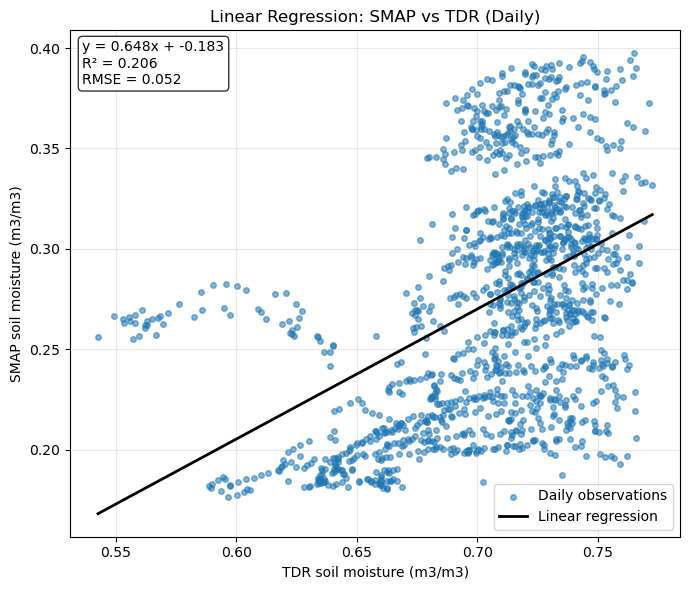

Visualization saved to: C:\Soilgrids\analysis\results_figures\results_sm_tdr_vs_smap_exponential_regression.png


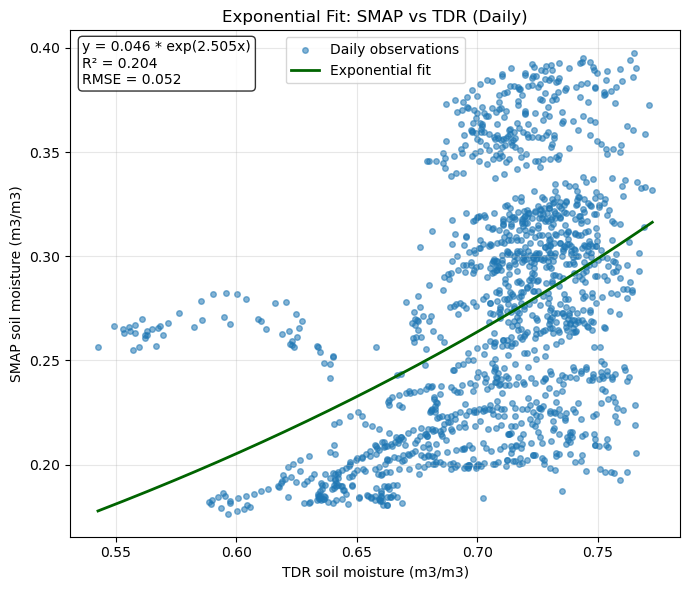

Visualization saved to: C:\Soilgrids\analysis\results_figures\results_sm_tdr_vs_smap_quadratic_regression.png


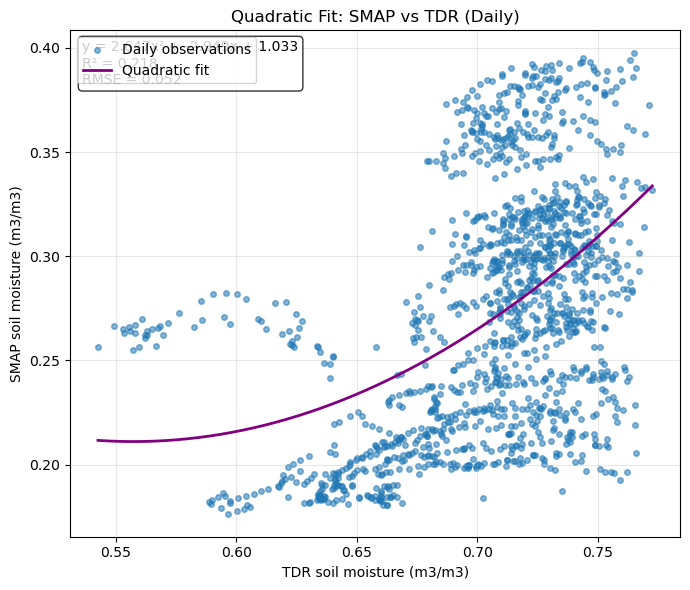

Visualization saved to: C:\Soilgrids\analysis\results_figures\results_sm_tdr_vs_smap_model_comparison.png


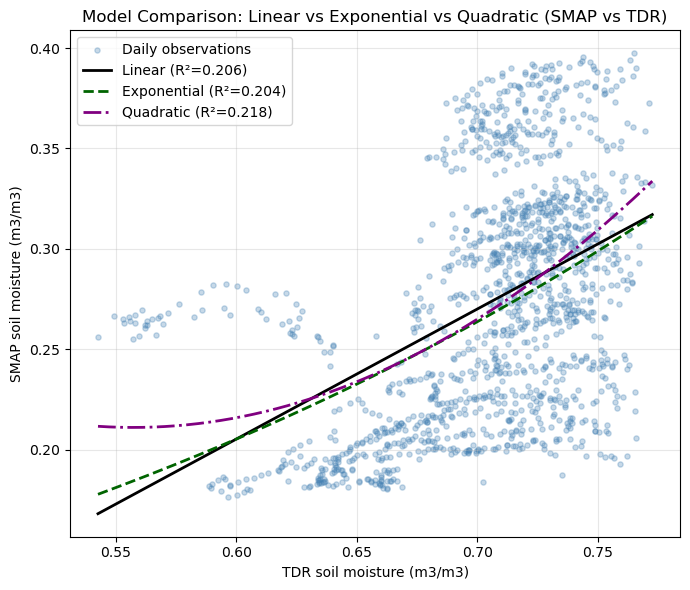

Model comparison (higher R² and lower RMSE are better):


,model,r_squared,rmse
0,quadratic,0.217991,0.051632
1,linear,0.205886,0.052030
2,exponential,0.203909,0.052094


In [53]:
# Regression models: linear vs exponential vs quadratic (SMAP vs TDR daily soil moisture)
if 'comparison' not in globals() or comparison.empty:
    raise ValueError("Run Cell 9 first so 'comparison' is available.")

x = comparison['tdr_soil_moisture'].to_numpy()
y = comparison['smap_soil_moisture'].to_numpy()

ss_tot = np.sum((y - np.mean(y)) ** 2)

# Linear model: y = m*x + b
lin_slope, lin_intercept = np.polyfit(x, y, 1)
y_hat_linear = lin_slope * x + lin_intercept
ss_res_linear = np.sum((y - y_hat_linear) ** 2)
r2_linear = 1 - (ss_res_linear / ss_tot) if ss_tot != 0 else np.nan
rmse_linear = np.sqrt(np.mean((y - y_hat_linear) ** 2))

# Exponential model: y = a * exp(b*x), fit by log-transform
if np.any(y <= 0):
    raise ValueError('Exponential fit requires strictly positive y values.')
exp_b, ln_exp_a = np.polyfit(x, np.log(y), 1)
exp_a = np.exp(ln_exp_a)
y_hat_exp = exp_a * np.exp(exp_b * x)
ss_res_exp = np.sum((y - y_hat_exp) ** 2)
r2_exp = 1 - (ss_res_exp / ss_tot) if ss_tot != 0 else np.nan
rmse_exp = np.sqrt(np.mean((y - y_hat_exp) ** 2))

# Quadratic model: y = a*x^2 + b*x + c
quad_a, quad_b, quad_c = np.polyfit(x, y, 2)
y_hat_quad = quad_a * x**2 + quad_b * x + quad_c
ss_res_quad = np.sum((y - y_hat_quad) ** 2)
r2_quad = 1 - (ss_res_quad / ss_tot) if ss_tot != 0 else np.nan
rmse_quad = np.sqrt(np.mean((y - y_hat_quad) ** 2))

x_line = np.linspace(x.min(), x.max(), 200)
y_line_linear = lin_slope * x_line + lin_intercept
y_line_exp = exp_a * np.exp(exp_b * x_line)
y_line_quad = quad_a * x_line**2 + quad_b * x_line + quad_c

# Chart 1: linear regression
fig_lin, ax_lin = plt.subplots(figsize=(7, 6))
ax_lin.scatter(x, y, alpha=0.55, s=16, label='Daily observations')
ax_lin.plot(x_line, y_line_linear, color='black', linewidth=2, label='Linear regression')
ax_lin.set_title('Linear Regression: SMAP vs TDR (Daily)')
ax_lin.set_xlabel('TDR soil moisture (m3/m3)')
ax_lin.set_ylabel('SMAP soil moisture (m3/m3)')
ax_lin.grid(alpha=0.3)
ax_lin.legend(loc='best')

lin_text = f"y = {lin_slope:.3f}x + {lin_intercept:.3f}\nR² = {r2_linear:.3f}\nRMSE = {rmse_linear:.3f}"
ax_lin.text(
    0.02, 0.98, lin_text,
    transform=ax_lin.transAxes,
    va='top',
    ha='left',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8)
 )
fig_lin.tight_layout()
save_figure(fig_lin, 'results_sm_tdr_vs_smap_linear_regression.png')
plt.show()

# Chart 2: exponential regression
fig_exp, ax_exp = plt.subplots(figsize=(7, 6))
ax_exp.scatter(x, y, alpha=0.55, s=16, label='Daily observations')
ax_exp.plot(x_line, y_line_exp, color='darkgreen', linewidth=2, label='Exponential fit')
ax_exp.set_title('Exponential Fit: SMAP vs TDR (Daily)')
ax_exp.set_xlabel('TDR soil moisture (m3/m3)')
ax_exp.set_ylabel('SMAP soil moisture (m3/m3)')
ax_exp.grid(alpha=0.3)
ax_exp.legend(loc='best')

exp_text = f"y = {exp_a:.3f} * exp({exp_b:.3f}x)\nR² = {r2_exp:.3f}\nRMSE = {rmse_exp:.3f}"
ax_exp.text(
    0.02, 0.98, exp_text,
    transform=ax_exp.transAxes,
    va='top',
    ha='left',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8)
 )
fig_exp.tight_layout()
save_figure(fig_exp, 'results_sm_tdr_vs_smap_exponential_regression.png')
plt.show()

# Chart 3: quadratic regression
fig_quad, ax_quad = plt.subplots(figsize=(7, 6))
ax_quad.scatter(x, y, alpha=0.55, s=16, label='Daily observations')
ax_quad.plot(x_line, y_line_quad, color='purple', linewidth=2, label='Quadratic fit')
ax_quad.set_title('Quadratic Fit: SMAP vs TDR (Daily)')
ax_quad.set_xlabel('TDR soil moisture (m3/m3)')
ax_quad.set_ylabel('SMAP soil moisture (m3/m3)')
ax_quad.grid(alpha=0.3)
ax_quad.legend(loc='best')

quad_text = f"y = {quad_a:.3f}x² + {quad_b:.3f}x + {quad_c:.3f}\nR² = {r2_quad:.3f}\nRMSE = {rmse_quad:.3f}"
ax_quad.text(
    0.02, 0.98, quad_text,
    transform=ax_quad.transAxes,
    va='top',
    ha='left',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8)
 )
fig_quad.tight_layout()
save_figure(fig_quad, 'results_sm_tdr_vs_smap_quadratic_regression.png')
plt.show()

# Chart 4: direct model comparison (all fits on one plot)
fig_cmp_fit, ax_cmp_fit = plt.subplots(figsize=(7, 6))
ax_cmp_fit.scatter(x, y, alpha=0.30, s=14, color='steelblue', label='Daily observations')
ax_cmp_fit.plot(x_line, y_line_linear, color='black', linewidth=2, label=f'Linear (R²={r2_linear:.3f})')
ax_cmp_fit.plot(x_line, y_line_exp, color='darkgreen', linewidth=2, linestyle='--', label=f'Exponential (R²={r2_exp:.3f})')
ax_cmp_fit.plot(x_line, y_line_quad, color='purple', linewidth=2, linestyle='-.', label=f'Quadratic (R²={r2_quad:.3f})')
ax_cmp_fit.set_title('Model Comparison: Linear vs Exponential vs Quadratic (SMAP vs TDR)')
ax_cmp_fit.set_xlabel('TDR soil moisture (m3/m3)')
ax_cmp_fit.set_ylabel('SMAP soil moisture (m3/m3)')
ax_cmp_fit.grid(alpha=0.3)
ax_cmp_fit.legend(loc='best')
fig_cmp_fit.tight_layout()
save_figure(fig_cmp_fit, 'results_sm_tdr_vs_smap_model_comparison.png')
plt.show()

model_comparison = pd.DataFrame({
    'model': ['linear', 'exponential', 'quadratic'],
    'r_squared': [r2_linear, r2_exp, r2_quad],
    'rmse': [rmse_linear, rmse_exp, rmse_quad]
}).sort_values('r_squared', ascending=False).reset_index(drop=True)

print('Model comparison (higher R² and lower RMSE are better):')
display(model_comparison)

Overlap-only SMAP vs TDR
Days used: 1410
Correlation (R): 0.4537
RMSE: 0.4351
Bias (SMAP - TDR): -0.4317
Saved overlap-only table to: C:\Soilgrids\resultados\comparison_smap_vs_tdr_overlap_only.csv
Missing TDR days marked in red: 248
Visualization saved to: C:\Soilgrids\analysis\results_figures\results_sm_continuous_smap_missing_tdr.png


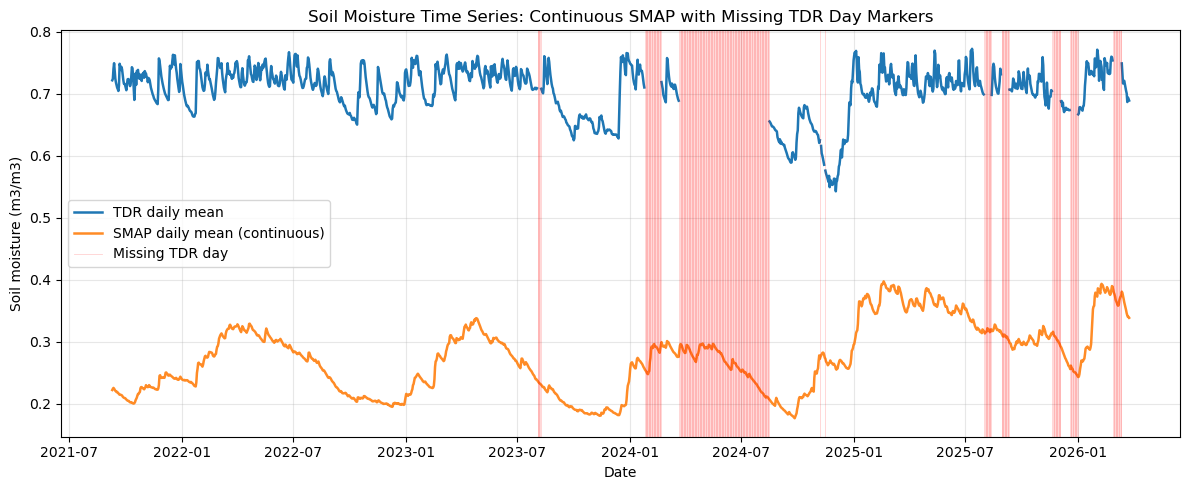

In [54]:
# Overlap-focused metrics, with continuous SMAP and missing TDR day markers
tdr = load_tdr_clean().rename(columns={'VW_mean_all_sensors': 'tdr_soil_moisture'})
smap_daily = load_smap_daily().rename(columns={'soil_moisture': 'smap_soil_moisture'})

overlap = pd.merge(tdr, smap_daily, on='Date', how='inner').sort_values('Date')
overlap = overlap[
    overlap['tdr_soil_moisture'].between(0, 1)
    & overlap['smap_soil_moisture'].between(0, 1)
]

r_overlap = overlap['tdr_soil_moisture'].corr(overlap['smap_soil_moisture'])
rmse_overlap = np.sqrt(np.mean((overlap['smap_soil_moisture'] - overlap['tdr_soil_moisture']) ** 2))
bias_overlap = np.mean(overlap['smap_soil_moisture'] - overlap['tdr_soil_moisture'])

print('Overlap-only SMAP vs TDR')
print(f'Days used: {len(overlap)}')
print(f'Correlation (R): {r_overlap:.4f}')
print(f'RMSE: {rmse_overlap:.4f}')
print(f'Bias (SMAP - TDR): {bias_overlap:.4f}')

overlap.to_csv(COMPARISON_OVERLAP_PATH, index=False)
print(f'Saved overlap-only table to: {COMPARISON_OVERLAP_PATH}')

plot_timeline = pd.date_range(smap_daily['Date'].min(), smap_daily['Date'].max(), freq='D')
smap_plot = smap_daily.set_index('Date').reindex(plot_timeline)['smap_soil_moisture']

tdr_plot_src = tdr.copy()
tdr_plot_src.loc[~tdr_plot_src['tdr_soil_moisture'].between(0, 1), 'tdr_soil_moisture'] = np.nan
tdr_plot = tdr_plot_src.set_index('Date').reindex(plot_timeline)['tdr_soil_moisture']

missing_tdr_days = tdr_plot.index[tdr_plot.isna() & smap_plot.notna()]
print(f'Missing TDR days marked in red: {len(missing_tdr_days)}')

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(plot_timeline, tdr_plot, label='TDR daily mean', linewidth=1.8)
ax.plot(plot_timeline, smap_plot, label='SMAP daily mean (continuous)', linewidth=1.8, alpha=0.9)

for index, day in enumerate(missing_tdr_days):
    ax.axvline(
        day,
        color='red',
        linewidth=0.6,
        alpha=0.18,
        label='Missing TDR day' if index == 0 else None
    )

ax.set_title('Soil Moisture Time Series: Continuous SMAP with Missing TDR Day Markers')
ax.set_xlabel('Date')
ax.set_ylabel('Soil moisture (m3/m3)')
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
save_figure(fig, 'results_sm_continuous_smap_missing_tdr.png')
plt.show()

Missing TDR days marked in red (z-score plot): 248
Visualization saved to: C:\Soilgrids\analysis\results_figures\results_sm_zscore_continuous_smap.png


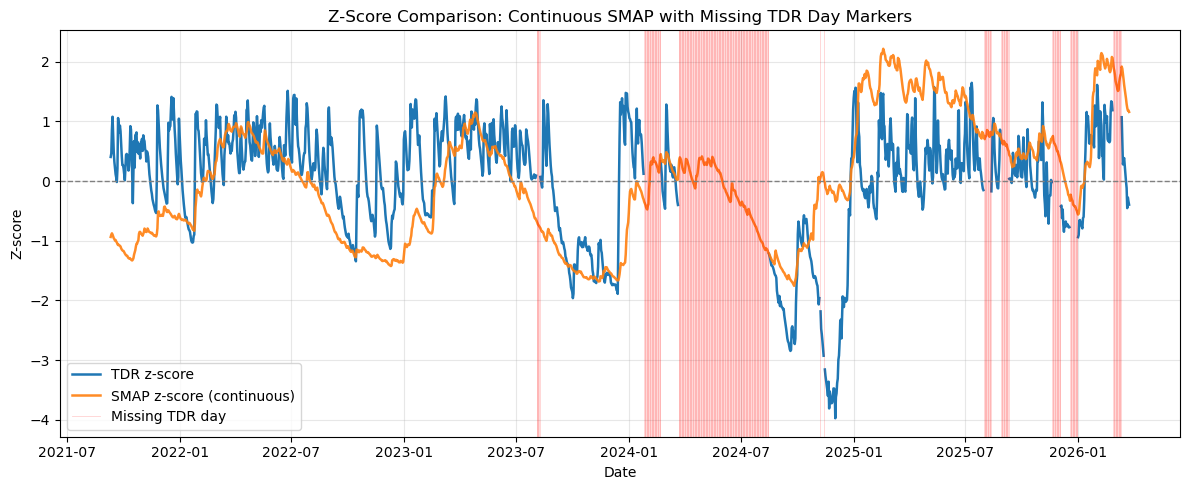

Missing days shown as breaks in overlap-only z-score plot: 248
Visualization saved to: C:\Soilgrids\analysis\results_figures\results_sm_zscore_overlap_only.png


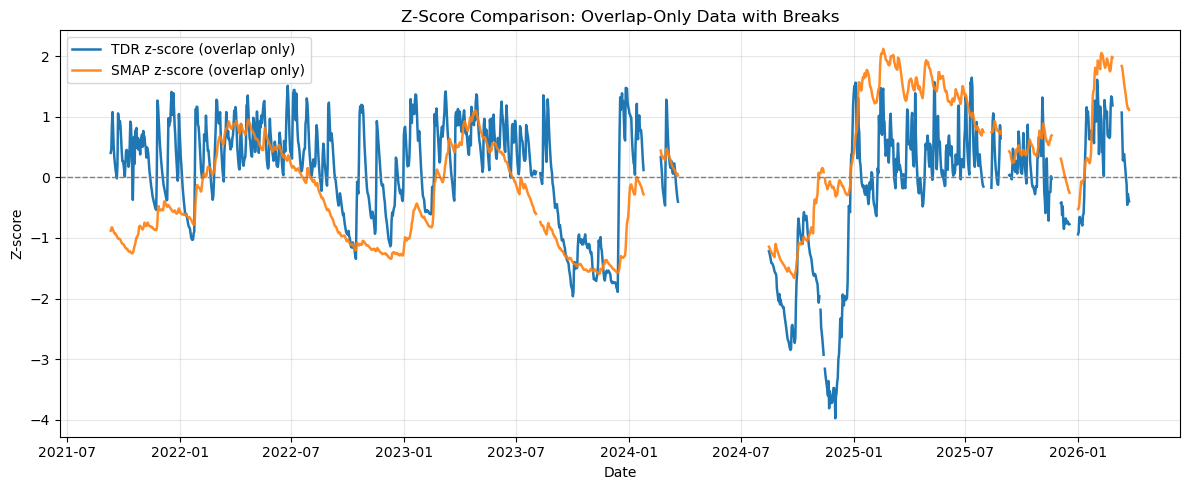

,Date,tdr_z,smap_z
0,2021-09-10,0.403614,-0.879903
1,2021-09-11,0.462675,-0.846362
2,2021-09-12,0.858089,-0.822601
3,2021-09-13,1.077399,-0.842688
4,2021-09-14,0.759715,-0.872633


In [55]:
# Z-score views for SMAP and TDR
overlap_z = pd.read_csv(COMPARISON_OVERLAP_PATH, parse_dates=['Date']).sort_values('Date')

tdr_z = (overlap_z['tdr_soil_moisture'] - overlap_z['tdr_soil_moisture'].mean()) / overlap_z['tdr_soil_moisture'].std()
smap_z = (overlap_z['smap_soil_moisture'] - overlap_z['smap_soil_moisture'].mean()) / overlap_z['smap_soil_moisture'].std()

z_df = pd.DataFrame({
    'Date': overlap_z['Date'],
    'tdr_z': tdr_z,
    'smap_z': smap_z
}).set_index('Date')

smap_full_daily = load_smap_daily()
smap_full_daily['smap_z_full'] = (
    smap_full_daily['soil_moisture'] - smap_full_daily['soil_moisture'].mean()
 ) / smap_full_daily['soil_moisture'].std()

tdr_clean_full = load_tdr_clean().drop_duplicates(subset='Date').sort_values('Date')
missing_days = pd.read_csv(MISSING_DATES_PATH, parse_dates=['date'])
missing_days['date'] = pd.to_datetime(missing_days['date']).dt.normalize()
missing_set = set(missing_days['date'])

tdr_values = tdr_clean_full['VW_mean_all_sensors'].where(
    tdr_clean_full['VW_mean_all_sensors'].between(0, 1)
)
tdr_clean_full['tdr_z_full'] = (tdr_values - tdr_values.mean()) / tdr_values.std()

z_timeline = pd.date_range(smap_full_daily['Date'].min(), smap_full_daily['Date'].max(), freq='D')
smap_z_plot = smap_full_daily.set_index('Date').reindex(z_timeline)['smap_z_full']
tdr_z_plot = tdr_clean_full.set_index('Date').reindex(z_timeline)['tdr_z_full']
tdr_z_plot.loc[tdr_z_plot.index.isin(missing_set)] = pd.NA

missing_tdr_days_z = tdr_z_plot.index[tdr_z_plot.isna() & smap_z_plot.notna()]
print(f'Missing TDR days marked in red (z-score plot): {len(missing_tdr_days_z)}')

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(z_timeline, tdr_z_plot, label='TDR z-score', linewidth=1.8)
ax.plot(z_timeline, smap_z_plot, label='SMAP z-score (continuous)', linewidth=1.8, alpha=0.9)

for index, day in enumerate(missing_tdr_days_z):
    ax.axvline(
        day,
        color='red',
        linewidth=0.6,
        alpha=0.18,
        label='Missing TDR day' if index == 0 else None
    )

ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_title('Z-Score Comparison: Continuous SMAP with Missing TDR Day Markers')
ax.set_xlabel('Date')
ax.set_ylabel('Z-score')
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
save_figure(fig, 'results_sm_zscore_continuous_smap.png')
plt.show()

z_timeline_overlap = pd.date_range(z_df.index.min(), z_df.index.max(), freq='D')
z_plot_overlap = z_df.reindex(z_timeline_overlap)

print(f"Missing days shown as breaks in overlap-only z-score plot: {z_plot_overlap['tdr_z'].isna().sum()}")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(z_timeline_overlap, z_plot_overlap['tdr_z'], label='TDR z-score (overlap only)', linewidth=1.8)
ax.plot(z_timeline_overlap, z_plot_overlap['smap_z'], label='SMAP z-score (overlap only)', linewidth=1.8, alpha=0.9)
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_title('Z-Score Comparison: Overlap-Only Data with Breaks')
ax.set_xlabel('Date')
ax.set_ylabel('Z-score')
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
save_figure(fig, 'results_sm_zscore_overlap_only.png')
plt.show()

z_plot_overlap.reset_index().rename(columns={'index': 'Date'}).head()

Monthly overlap used: 51 months
Visualization saved to: C:\Soilgrids\analysis\results_figures\results_sm_zscore_monthly_averages.png


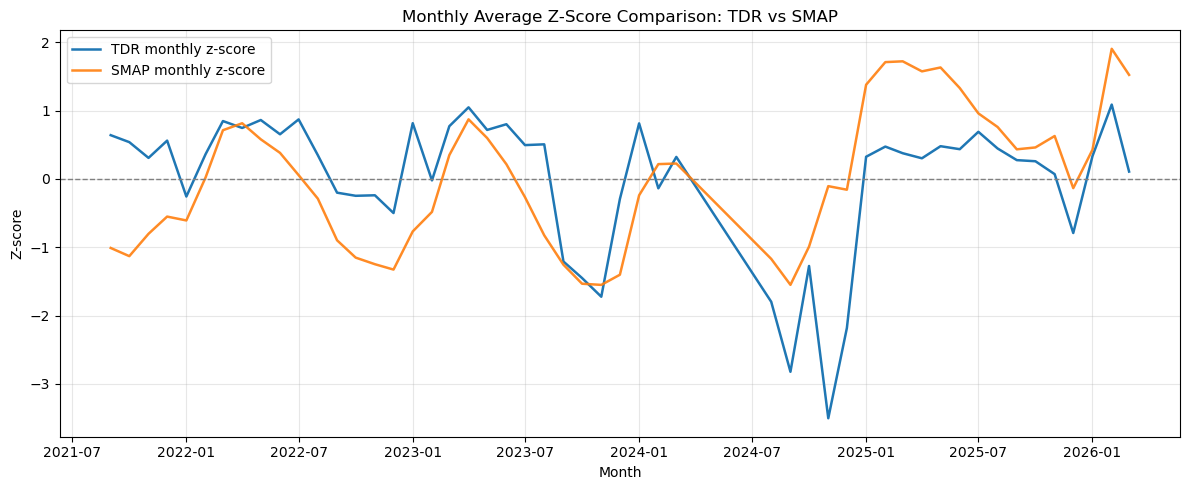

,Month,tdr_monthly_mean,smap_monthly_mean,tdr_monthly_z,smap_monthly_z
0,2021-09-01,0.726807,0.217048,0.639425,-1.010547
1,2021-10-01,0.723288,0.210204,0.537431,-1.130308
2,2021-11-01,0.715335,0.228883,0.306966,-0.803463
3,2021-12-01,0.724057,0.243277,0.559727,-0.551593
4,2022-01-01,0.695830,0.240050,-0.258288,-0.608058


In [56]:
# Monthly-average z-score comparison for TDR and SMAP
tdr_monthly = load_tdr_clean().copy()
tdr_monthly['Month'] = tdr_monthly['Date'].dt.to_period('M').dt.to_timestamp()
tdr_monthly = (
    tdr_monthly.groupby('Month', as_index=False)['VW_mean_all_sensors']
    .mean()
    .rename(columns={'VW_mean_all_sensors': 'tdr_monthly_mean'})
 )

smap_monthly = load_smap_daily().copy()
smap_monthly['Month'] = smap_monthly['Date'].dt.to_period('M').dt.to_timestamp()
smap_monthly = (
    smap_monthly.groupby('Month', as_index=False)['soil_moisture']
    .mean()
    .rename(columns={'soil_moisture': 'smap_monthly_mean'})
 )

monthly_comparison = pd.merge(tdr_monthly, smap_monthly, on='Month', how='inner').sort_values('Month')
monthly_comparison['tdr_monthly_z'] = (
    monthly_comparison['tdr_monthly_mean'] - monthly_comparison['tdr_monthly_mean'].mean()
 ) / monthly_comparison['tdr_monthly_mean'].std()
monthly_comparison['smap_monthly_z'] = (
    monthly_comparison['smap_monthly_mean'] - monthly_comparison['smap_monthly_mean'].mean()
 ) / monthly_comparison['smap_monthly_mean'].std()

print(f"Monthly overlap used: {len(monthly_comparison)} months")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(
    monthly_comparison['Month'],
    monthly_comparison['tdr_monthly_z'],
    label='TDR monthly z-score',
    linewidth=1.8
 )
ax.plot(
    monthly_comparison['Month'],
    monthly_comparison['smap_monthly_z'],
    label='SMAP monthly z-score',
    linewidth=1.8,
    alpha=0.9
 )
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_title('Monthly Average Z-Score Comparison: TDR vs SMAP')
ax.set_xlabel('Month')
ax.set_ylabel('Z-score')
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
save_figure(fig, 'results_sm_zscore_monthly_averages.png')
plt.show()

monthly_comparison.head()